In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, classification_report

from datasets import load_dataset
from collections import Counter

import numpy as np
import seaborn as sns
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import kagglehub, zipfile, os

from transformers import BertConfig, BertModel, BertTokenizerFast, BertForSequenceClassification, TrainingArguments, Trainer, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [ ]:
torch.cuda.empty_cache()

In [4]:
def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # <- add this line
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_random_seed(224)

In [5]:
data = pd.read_csv('/home/jupyter/datasphere/project/токсичность/labeled.csv')

In [ ]:
train_size = int(len(data) * 0.8)+1
val_size = int(len(data) * 0.1)
test_size = int(len(data) * 0.1)
print(train_size+val_size+test_size)

In [7]:
ds_train = data[0:train_size]
ds_val = data[train_size:train_size+val_size]
ds_test = data[train_size+val_size:train_size+val_size+test_size]

ds_train = ds_train.reset_index(drop=True)
ds_val = ds_val.reset_index(drop=True)
ds_test = ds_test.reset_index(drop=True)

In [8]:
def parse_dataset(filepath):
    texts, slots, classes = [], [], []
    with open(filepath, 'r', encoding='utf-8') as file:
        current_text, current_slots, current_classes = [], [], []
        text_id = 0
        for line in file:
            line = line.strip()
            if line.startswith('# sent_id'):
              c = line.split()[3]
              text, sent = c.split('_')
              if text_id != int(text):
                texts.append(current_text)
                slots.append(current_slots)
                classes.append(current_classes)
                text_id = int(text)
                current_text, current_slots, current_classes = [], [], []
            elif line.startswith('# text'):
              continue
            elif not line:  # конец предложения
              continue
            else:
                l = line.split('\t')
                current_text.append(l[1])
                current_classes.append(l[-1])
                current_slots.append(l[-2])
        # добавим последнее предложение на случай, если файл не заканчивался на пустую строчку
        if current_text:
          texts.append(current_text)
          slots.append(current_slots)
          classes.append(current_classes)
    return texts, slots, classes

In [9]:
from collections import defaultdict

def extract_classes_and_slots(filepath):
    classes = set()
    slots = set()

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            fields = line.split('\t')
            if len(fields) < 11:
                continue
            class_field = fields[11]
            slot_field = fields[10]
            #if class_field and class_field != '_':
            classes.add(class_field)
            #if slot_field and slot_field != '_':
            slots.add(slot_field)


    classes = sorted(classes)
    slots = sorted(slots)
    classes.append('PAD') # паддинга нет в датасете, но будет в текстах, надо включить
    slots.append('PAD')

    class2idx = {cls: idx for idx, cls in enumerate(classes)}
    idx2class = {idx: cls for cls, idx in class2idx.items()}

    slot2idx = {slot: idx for idx, slot in enumerate(slots)}
    idx2slot = {idx: slot for slot, idx in slot2idx.items()}

    return {
        'classes': classes,
        'slots': slots,
        'class2idx': class2idx,
        'idx2class': idx2class,
        'slot2idx': slot2idx,
        'idx2slot': idx2slot
    }

In [ ]:
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, slots, classes, slot2id, class2id, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.slots = slots # слоты и классы так же
        self.classes = classes
        self.slot2id = slot2id
        self.class2id = class2id
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)

    def align_tokens_and_labels(self, tokens, slots, classes):
        
        word_ids = self.tokenizer.convert_tokens_to_ids(tokens)  # Индексы токенов
        aligned_slots = []
        aligned_classes = []

        current_word_idx = 0
        for word in word_ids:
            # Получаем текущий токен из разметки
            current_word = tokens[current_word_idx]

            # Получаем количество токенов для текущего слова из разметки
            original_word_token_count = len(self.tokenizer.tokenize(current_word))

            # Присваиваем всем токенам этого слова одинаковый тег
            for _ in range(original_word_token_count):
                aligned_slots.append(slots[current_word_idx])
                aligned_classes.append(classes[current_word_idx])

            # Переходим к следующему слову в разметке
            current_word_idx += 1

        return aligned_slots, aligned_classes

    def slice_token(self, index):
        start, stop, step = index.indices(len(self.texts))
        result = []
        for i in range(start, stop, step):
            tokens = self.texts[i]
            classes = self.classes[i]
            slots = self.slots[i]
            label = self.labels[i]
            encoding = self.tokenizer(
                            tokens,
                            is_split_into_words=True,
                            padding='max_length',
                            truncation=True,
                            max_length=self.max_length,
                            return_tensors='pt'
                        )
            slots, classes = self.align_tokens_and_labels(tokens, slots, classes)

            pad_len = self.max_length - len(slots)
            if pad_len > 0:
                for i in range(pad_len):
                    slots.append('PAD')
                    classes.append('PAD')
            else:
                slots = slots[:self.max_length]
                classes = classes[:self.max_length]

            slots = [self.slot2id[slot] for slot in slots]
            classes = [self.class2id[cls] for cls in classes]
            slots = torch.tensor(slots, dtype=torch.long)
            classes = torch.tensor(classes, dtype=torch.long)

            encoding["slots"] = slots
            encoding["classes"] = classes
            encoding["label"] = torch.tensor(label, dtype=torch.long)
            encoding["input_ids"] = torch.squeeze(encoding["input_ids"], 0)
            encoding["token_type_ids"] = torch.squeeze(encoding["token_type_ids"], 0)
            encoding["attention_mask"] = torch.squeeze(encoding["attention_mask"], 0)

            result.append({key: torch.tensor(val) for key, val in encoding.items()})

        return result

    def __getitem__(self, idx):

        if isinstance(idx, slice):
            # Обработка среза
            return self.slice_token(idx)
        elif isinstance(idx, int):
            tokens = self.texts[idx]
            classes = self.classes[idx]
            slots = self.slots[idx]
            label = self.labels[idx]
            # токенизируем
            encoding = self.tokenizer(
                tokens,
                padding='max_length',
                is_split_into_words=True,
                truncation = True,
                max_length = self.max_length,
                return_tensors = 'pt'
            )
            slots, classes = self.align_tokens_and_labels(tokens, slots, classes)

            pad_len = self.max_length - len(slots)
            if pad_len > 0:
                for i in range(pad_len):
                    slots.append('PAD')
                    classes.append('PAD')
            else:
                slots = slots[:self.max_length]
                classes = classes[:self.max_length]

            slots = [self.slot2id[slot] for slot in slots]
            classes = [self.class2id[cls] for cls in classes]

            slots = torch.tensor(slots, dtype=torch.long)
            classes = torch.tensor(classes, dtype=torch.long)

            encoding["slots"] = slots
            encoding["classes"] = classes
            encoding["label"] = torch.tensor(label, dtype=torch.long)
            encoding["input_ids"] = torch.squeeze(encoding["input_ids"], 0)
            encoding["token_type_ids"] = torch.squeeze(encoding["token_type_ids"], 0)
            encoding["attention_mask"] = torch.squeeze(encoding["attention_mask"], 0)
            """
            item = {key: val.squeeze(0) for key, val in encoding.items()}  # Убираем batch dim
            item['labels'] = torch.tensor(tag, dtype=torch.long) # Без лишнего
            """
            return encoding

In [11]:
tokenizer = BertTokenizerFast.from_pretrained('DeepPavlov/rubert-base-cased')

/home/jupyter/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
texts, slots, classes = parse_dataset('/home/jupyter/datasphere/project/токсичность/labeled_pred.conllu')

def create_dataloader_train(labels, tokenizer, slots2id, classes2id, batch_size=32, max_length=512):
    dataset = ToxicDataset(texts[:train_size], labels, slots[:train_size], classes[:train_size], slots2id, classes2id, tokenizer, max_length=max_length)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False) #shuffle=True

def create_dataloader_val(labels, tokenizer, slots2id, classes2id, batch_size=32, max_length=512):
    dataset = ToxicDataset(texts[train_size:train_size+val_size], labels, slots[train_size:train_size+val_size], classes[train_size:train_size+val_size], slots2id, classes2id, tokenizer, max_length=max_length)
    return DataLoader(dataset, batch_size=batch_size, shuffle = False)

def create_dataloader_test(labels, tokenizer, slots2id, classes2id, batch_size=32, max_length=512):
    dataset = ToxicDataset(texts[train_size+val_size:train_size+val_size+test_size], labels, slots[train_size+val_size:train_size+val_size+test_size], classes[train_size+val_size:train_size+val_size+test_size], slots2id, classes2id, tokenizer, max_length=max_length)
    return DataLoader(dataset, batch_size=batch_size, shuffle = False)

In [ ]:
extracted = extract_classes_and_slots('/home/jupyter/datasphere/project/токсичность/labeled_pred.conllu')
train_dataloader = create_dataloader_train(ds_train['toxic'], tokenizer, extracted['slot2idx'], extracted['class2idx'], batch_size=32)
val_dataloader = create_dataloader_val(ds_val['toxic'], tokenizer, extracted['slot2idx'], extracted['class2idx'], batch_size=32)
test_dataloader = create_dataloader_test(ds_test['toxic'], tokenizer, extracted['slot2idx'], extracted['class2idx'], batch_size=32)

In [16]:
class BiLSTMPooling(nn.Module):
    def __init__(self, emb_dim, hidden_size=256):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_size,
            bidirectional=True,
            batch_first=True
        )

    def forward(self, token_embeddings):
        # token_embeddings: [batch_size, seq_len, emb_dim]
        lstm_out, _ = self.lstm(token_embeddings)  # [batch_size, seq_len, 2*hidden_size]
        return lstm_out.mean(dim=1)  # Mean pooling over sequence

In [ ]:
class ToxicClassifier(nn.Module):
  def __init__(self, num_labels, num_semantic_classes, num_semantic_slots, semantic_emb_dim=512, lstm_hidden_size=256):
    super().__init__()
    self.bert = BertModel.from_pretrained("DeepPavlov/rubert-base-cased")
    self.drop = nn.Dropout(p=0.3)
    self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
    self.loss_fct = nn.CrossEntropyLoss()

  def forward(self, input_ids=None, token_type_ids=None, attention_mask=None):
    _, pooled_output = self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask,
      return_dict=False)

    return self.classifier(pooled_output)

In [ ]:
num_labels = 2
num_semantic_classes = len(extracted['classes'])
num_semantic_slots = len(extracted['slots'])

model = ToxicClassifier(num_labels=num_labels,
    num_semantic_classes=num_semantic_classes,
    num_semantic_slots=num_semantic_slots)

In [19]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [20]:
EPOCHS = 3

#optimizer = AdamW(model.parameters(), lr=2e-5, correct_bias=False)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5) #correct_bias=False
total_steps = len(train_dataloader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

In [ ]:
def train_epoch(
  model,
  data_loader,
  loss_fn,
  optimizer,
  device,
  scheduler,
  n_examples
):
  model = model.train()

  losses = []
  correct_predictions = 0
  all_preds = []
  all_labels = []


  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["label"].to(device)


    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask)

    loss = loss_fn(outputs, targets)

    all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
    all_labels.extend(targets.cpu().numpy())

    losses.append(loss.item())

    loss.backward()
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  precision, recall, f1, _ = precision_recall_fscore_support(
  all_labels, all_preds, average='binary', zero_division=0)
  acc = accuracy_score(all_labels, all_preds)
  print(confusion_matrix(all_labels, all_preds))

  return precision, recall, f1, acc, np.mean(losses)

In [ ]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["label"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )

      loss = loss_fn(outputs, targets)

      all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
      all_labels.extend(targets.cpu().numpy())

      losses.append(loss.item())

  precision, recall, f1, _ = precision_recall_fscore_support(
  all_labels, all_preds, average='binary', zero_division=0)
  acc = accuracy_score(all_labels, all_preds)
  print(confusion_matrix(all_labels, all_preds))

  return precision, recall, f1, acc, np.mean(losses)

In [24]:
%%time

history = defaultdict(list)
#best_accuracy = 0

for epoch in range(EPOCHS):

  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_precision, train_recall, train_f1, train_acc, train_loss = train_epoch(
    model,
    train_dataloader,
    loss_fn,
    optimizer,
    device,
    scheduler,
    len(ds_train)
  )

  print(f'Train loss {train_loss} train_acc {train_acc} train_precision {train_precision}, train_recall {train_recall}, train_f1 {train_f1}')

  val_precision, val_recall, val_f1, val_acc, val_loss = eval_model(
    model,
  val_dataloader,
    loss_fn,
    device,
    len(ds_val)
  )

  print(f'Val loss {val_loss} val_acc {val_acc} val_precision {val_precision}, val_recall {val_recall}, val_f1 {val_f1}')
  print()

  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)


  """
  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'best_model_state.bin')
    best_accuracy = val_metrics['accuracy']
  """

Epoch 1/3
----------
[[6663  995]
 [ 808 3064]]
Train loss 0.34314876151918705 train_acc 0.8436253252385082 train_precision 0.7548657304754866, train_recall 0.7913223140495868, train_f1 0.7726642289749086
[[1168   28]
 [  30  215]]
Val loss 0.11934113206908754 val_acc 0.9597501734906315 val_precision 0.8847736625514403, val_recall 0.8775510204081632, val_f1 0.8811475409836066

Epoch 2/3
----------
[[6891  767]
 [ 479 3393]]
Train loss 0.27070240702975407 train_acc 0.8919340849956635 train_precision 0.815625, train_recall 0.8762913223140496, train_f1 0.8448705179282868
[[1162   34]
 [  32  213]]
Val loss 0.11951718216195055 val_acc 0.9541984732824428 val_precision 0.8623481781376519, val_recall 0.8693877551020408, val_f1 0.8658536585365854

Epoch 3/3
----------
[[7177  481]
 [ 394 3478]]
Train loss 0.19038027733141283 train_acc 0.9241110147441457 train_precision 0.8785046728971962, train_recall 0.8982438016528925, train_f1 0.8882645894521772
[[1164   32]
 [  30  215]]
Val loss 0.1236922

In [25]:
history['train_acc'] = [score for score in  history['train_acc']]
history['val_acc'] = [score for score in  history['val_acc']]

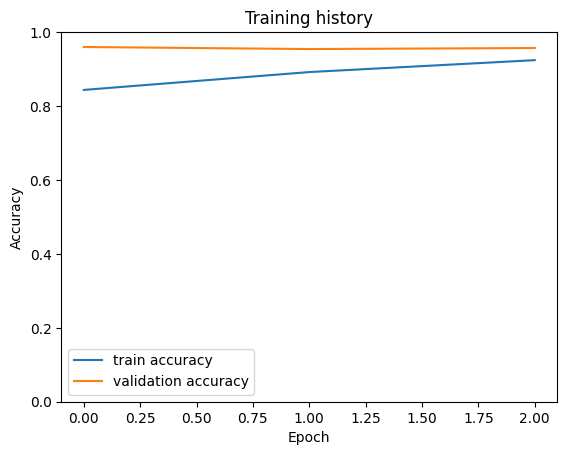

In [26]:
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

In [27]:
test_precision, test_recall, test_f1, test_acc, test_loss = eval_model(
  model,
  test_dataloader,
  loss_fn,
  device,
  len(ds_test)
)

print(test_precision, test_recall, test_f1, test_acc, test_loss)

[[699  33]
 [ 42 667]]
0.9528571428571428 0.9407616361071932 0.9467707594038325 0.9479528105482304 0.14909565780797732


In [ ]:
def get_predictions(model, data_loader):
  model = model.eval()

  #review_texts = []
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:

      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["label"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
      )
      preds = torch.argmax(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()
  return predictions, prediction_probs, real_values

In [29]:
y_pred, y_pred_probs, y_test = get_predictions(model, test_dataloader)

In [30]:
print(classification_report(y_test, y_pred, target_names=['0', '1']))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       732
           1       0.95      0.94      0.95       709

    accuracy                           0.95      1441
   macro avg       0.95      0.95      0.95      1441
weighted avg       0.95      0.95      0.95      1441



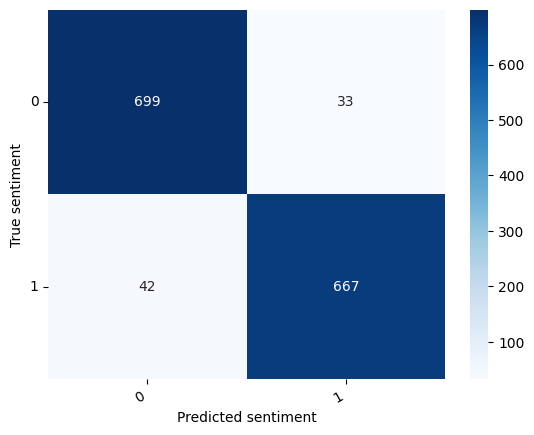

In [31]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True sentiment')
  plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=['0', '1'], columns=['0', '1'])
show_confusion_matrix(df_cm)

In [32]:
def show_misclassified(model, data_loader, device, tokenizer, label_names=None, max_examples=50):
    model.eval()
    mistakes = []

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["label"].to(device)

            # Другие поля, если нужно (например, slots/classes), можно также передать
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs if isinstance(outputs, torch.Tensor) else outputs[0]

            preds = torch.argmax(logits, dim=1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    text = tokenizer.decode(
                        input_ids[i],
                        skip_special_tokens=True,
                        clean_up_tokenization_spaces=True
                    )
                    true_label = labels[i].item()
                    pred_label = preds[i].item()
                    mistakes.append((text, true_label, pred_label))

                if len(mistakes) >= max_examples:
                    break
            if len(mistakes) >= max_examples:
                break

    for i, (text, true_label, pred_label) in enumerate(mistakes, 1):
        true_name = label_names[true_label] if label_names else true_label
        pred_name = label_names[pred_label] if label_names else pred_label
        print(f"\n[{i}] ❌ Wrong prediction")
        print(f"📌 Text: {text}")
        print(f"✅ True: {true_name}")
        print(f"🚫 Pred: {pred_name}")

In [33]:
show_misclassified(model, test_dataloader, device, tokenizer, label_names=[1, 0])


[1] ❌ Wrong prediction
📌 Text: Я # NULL не конкретно про этот случай. Чаще на дороге встречаются неадекватные мотоциклисты, нежели нормальные # NULL.
✅ True: 0
🚫 Pred: 1

[2] ❌ Wrong prediction
📌 Text: Зря тут # NULL этот пост. Теперь дом спиздят
✅ True: 0
🚫 Pred: 1

[3] ❌ Wrong prediction
📌 Text: Вы правда считаете, что быдлокодер вашего софта на ПК и генно - кодер это один и тот же человек?
✅ True: 0
🚫 Pred: 1

[4] ❌ Wrong prediction
📌 Text: # NULL Похоже на мох, что в тундре у нас растет. Называют Ягель. Им олени питаются
✅ True: 0
🚫 Pred: 1

[5] ❌ Wrong prediction
📌 Text: по описанию его # NULL проще собрать из говна и палок нежели искать готовый
✅ True: 1
🚫 Pred: 0

[6] ❌ Wrong prediction
📌 Text: Хотел тоже самое # NULL на оф форуме написать ( только без упоминания негров, там модеры такое # NULL не любят ), вот только меня забанили. Свобода слова )
✅ True: 0
🚫 Pred: 1

[7] ❌ Wrong prediction
📌 Text: Просто место намоленое
✅ True: 0
🚫 Pred: 1

[8] ❌ Wrong prediction
📌 Text: # NUL